In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Specify the path to your data file in Google Drive
data_path = '/content/drive/MyDrive/depi/Machine learning/cicids2017_cleaned.csv'

# Load the data into a pandas DataFrame
df = pd.read_csv(data_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [4]:
import numpy as np
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("\nZero percentages:")
print(
    ((df.select_dtypes(include=np.number) == 0).mean() * 100)
    .sort_values(ascending=False)
    .head(15)
)

Shape: (2520751, 53)

Missing values:
0

Infinite values:
0

Zero percentages:
FIN Flag Count           96.790401
Active Mean              77.832083
Active Max               77.832083
Active Min               77.832083
Idle Min                 77.498492
Idle Mean                77.498492
Idle Max                 77.498492
PSH Flag Count           70.238869
ACK Flag Count           68.813778
Bwd Packet Length Std    68.112201
Bwd IAT Std              67.821534
Fwd Packet Length Std    61.433597
Fwd IAT Std              58.445598
Bwd Packet Length Min    50.974531
Min Packet Length        48.449331
dtype: float64


In [5]:
zero_percentage = (df == 0).mean() * 100

zero_percentage.sort_values(ascending=False).head(15)

,0
FIN Flag Count,96.790401
Active Max,77.832083
Active Min,77.832083
Active Mean,77.832083
Idle Min,77.498492
Idle Max,77.498492
Idle Mean,77.498492
PSH Flag Count,70.238869
ACK Flag Count,68.813778
Bwd Packet Length Std,68.112201


In [6]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

----------------------------------------
-------------------------------------------------

In [7]:
from sklearn.model_selection import train_test_split

# ============================================
# 1. Create Binary Label
# ============================================

df["Binary Label"] = (
    df["Attack Type"] != "Normal Traffic"
).astype(int)

print("Original class distribution:")
print(df["Binary Label"].value_counts())

print("\nPercentage:")
print(df["Binary Label"].value_counts(normalize=True) * 100)


Original class distribution:
Binary Label
0    2095057
1     425694
Name: count, dtype: int64

Percentage:
Binary Label
0    83.112414
1    16.887586
Name: proportion, dtype: float64


In [8]:
# ============================================
# 2. Separate Features and Target
# ============================================

X = df.drop(
    ["Binary Label", "Attack Type"],
    axis=1
)

y = df["Binary Label"]



In [9]:
# ============================================
# 3. Train-Test Split BEFORE Undersampling
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nBefore undersampling:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())



Before undersampling:
X_train: (2016600, 52)
X_test: (504151, 52)

y_train:
Binary Label
0    1676045
1     340555
Name: count, dtype: int64

y_test:
Binary Label
0    419012
1     85139
Name: count, dtype: int64


In [10]:
# ============================================
# 4. Undersampling ONLY the Training Set
# ============================================

train_df = X_train.copy()
train_df["Binary Label"] = y_train.values

normal = train_df[train_df["Binary Label"] == 0]
attack = train_df[train_df["Binary Label"] == 1]

normal_sample = normal.sample(
    n=len(attack),
    random_state=42
)

balanced_train = pd.concat(
    [normal_sample, attack],
    ignore_index=True
)

# Shuffle
balanced_train = balanced_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


In [11]:
# ============================================
# 5. Create Final Training Data
# ============================================

X_train = balanced_train.drop(
    "Binary Label",
    axis=1
)

y_train = balanced_train["Binary Label"]




In [12]:
# ============================================
# 6. Final Check
# ============================================

print("\nAfter undersampling:")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())


After undersampling:
X_train: (681110, 52)
X_test: (504151, 52)

y_train:
Binary Label
0    340555
1    340555
Name: count, dtype: int64

y_test:
Binary Label
0    419012
1     85139
Name: count, dtype: int64


In [13]:
print("Missing values:")
print(X_train.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

print("\nData types:")
print(X_train.dtypes.value_counts())

Missing values:
0

Infinite values:
0

Data types:
int64      32
float64    20
Name: count, dtype: int64


In [14]:
print("\nDuplicated rows:")
print("Train:", X_train.duplicated().sum())
print("Test:", X_test.duplicated().sum())


Duplicated rows:
Train: 106
Test: 37


In [15]:
print("\nTraining set statistics:")
display(X_train.describe().T)


Training set statistics:


,count,mean,std,min,25%,50%,75%,max
Destination Port,681110.0,6.032408e+03,1.582765e+04,0.000000e+00,80.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,681110.0,2.526067e+07,4.066758e+07,-1.000000e+00,232.000000,152609.500000,6.104026e+07,1.200000e+08
Total Fwd Packets,681110.0,7.646606e+00,5.157691e+02,1.000000e+00,2.000000,3.000000,7.000000e+00,2.039430e+05
Total Length of Fwd Packets,681110.0,4.488074e+02,4.348279e+03,0.000000e+00,12.000000,58.000000,3.470000e+02,1.224076e+06
Fwd Packet Length Max,681110.0,1.987378e+02,6.059671e+02,0.000000e+00,6.000000,35.000000,3.220000e+02,2.336000e+04
Fwd Packet Length Min,681110.0,1.207484e+01,4.894951e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,2.065000e+03
Fwd Packet Length Mean,681110.0,5.073928e+01,1.578352e+02,0.000000e+00,6.000000,32.000000,5.200000e+01,5.939286e+03
Fwd Packet Length Std,681110.0,7.074468e+01,2.377824e+02,0.000000e+00,0.000000,0.000000,1.170262e+02,5.797500e+03
Bwd Packet Length Max,681110.0,2.047410e+03,3.027821e+03,0.000000e+00,6.000000,113.000000,4.344000e+03,1.448000e+04
Bwd Packet Length Min,681110.0,2.646682e+01,5.933376e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,1.983000e+03


In [16]:
print("Duplicated rows including label:")

train_full = X_train.copy()
train_full["Binary Label"] = y_train.values

test_full = X_test.copy()
test_full["Binary Label"] = y_test.values

print("Train duplicates:", train_full.duplicated().sum())
print("Test duplicates:", test_full.duplicated().sum())

Duplicated rows including label:
Train duplicates: 4
Test duplicates: 7


In [17]:
train_hash = pd.util.hash_pandas_object(train_full, index=False)
test_hash = pd.util.hash_pandas_object(test_full, index=False)

print("Exact duplicates between train and test:",
      len(set(train_hash) & set(test_hash)))

Exact duplicates between train and test: 13


In [18]:
negative_counts = (X_train < 0).sum()

negative_counts = negative_counts[
    negative_counts > 0
].sort_values(ascending=False)

print("Features containing negative values:")
display(negative_counts)

Features containing negative values:


,0
Init_Win_bytes_backward,237717
Init_Win_bytes_forward,147541
Flow IAT Min,573
Flow Duration,17
Flow Packets/s,17
Flow IAT Mean,17
Flow IAT Max,17
Fwd IAT Min,15
Flow Bytes/s,13
Fwd Header Length,7


In [19]:
negative_percentage = (
    (X_train < 0).mean() * 100
)

negative_percentage = negative_percentage[
    negative_percentage > 0
].sort_values(ascending=False)

print("Percentage of negative values:")
display(negative_percentage)

Percentage of negative values:


,0
Init_Win_bytes_backward,34.901411
Init_Win_bytes_forward,21.661846
Flow IAT Min,0.084127
Flow Duration,0.002496
Flow Packets/s,0.002496
Flow IAT Mean,0.002496
Flow IAT Max,0.002496
Fwd IAT Min,0.002202
Flow Bytes/s,0.001909
Fwd Header Length,0.001028


In [20]:
suspicious_features = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Min",
    "Fwd Header Length",
    "Bwd Header Length",
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward",
    "min_seg_size_forward"
]

for col in suspicious_features:
    if col in X_train.columns:
        print(f"\n{col}")
        print(X_train[col].nsmallest(10).values)


Flow Duration
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Flow Bytes/s
[-12000000. -12000000. -12000000. -12000000. -12000000. -12000000.
  -8000000.  -8000000.  -8000000.  -6000000.]

Flow Packets/s
[-2000000. -2000000. -2000000. -2000000. -2000000. -2000000. -2000000.
 -2000000. -2000000. -2000000.]

Flow IAT Mean
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]

Flow IAT Max
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Flow IAT Min
[-14 -13 -13 -13 -13 -12 -12 -12 -12 -12]

Fwd IAT Min
[-8 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Fwd Header Length
[-1073741218  -167770490  -167770470   -83885221   -83885137   -83885133
   -83885093           0           0           0]

Bwd Header Length
[-1073741218  -167770490  -167770470   -83885221   -83885137   -83885133
   -83885093           0           0           0]

Init_Win_bytes_forward
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Init_Win_bytes_backward
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

min_seg_size_forward
[-536870661  -83885313  -83885313  -83885313  -83885313  -83885313
  -83885313      

In [21]:
# ============================================
# Inspect suspicious rows
# ============================================

cols_to_check = [
    "Fwd Header Length",
    "Bwd Header Length",
    "min_seg_size_forward"
]

mask = (
    (X_train["Fwd Header Length"] < 0) |
    (X_train["Bwd Header Length"] < 0) |
    (X_train["min_seg_size_forward"] < 0)
)

print("Number of suspicious rows:", mask.sum())

display(
    X_train.loc[
        mask,
        cols_to_check
    ]
)

Number of suspicious rows: 7


,Fwd Header Length,Bwd Header Length,min_seg_size_forward
84731,-167770490,-167770490,-83885313
96842,-83885137,-83885137,-83885313
117444,-167770470,-167770470,-83885313
120650,-83885093,-83885093,-83885313
166691,-83885133,-83885133,-83885313
260432,-1073741218,-1073741218,-536870661
376356,-83885221,-83885221,-83885313


In [22]:
print("Labels of suspicious rows:")

display(
    y_train.loc[mask].value_counts()
)

Labels of suspicious rows:


,count
Binary Label,
0,7


In [23]:
print("Original suspicious rows:")

display(
    df.loc[
        (df["Fwd Header Length"] < 0) |
        (df["Bwd Header Length"] < 0) |
        (df["min_seg_size_forward"] < 0),
        [
            "Fwd Header Length",
            "Bwd Header Length",
            "min_seg_size_forward",
            "Attack Type",
            "Binary Label"
        ]
    ]
)

Original suspicious rows:


,Fwd Header Length,Bwd Header Length,min_seg_size_forward,Attack Type,Binary Label
375466,-1073741218,-1073741218,-536870661,Normal Traffic,0
375473,-9663668122,0,-536870661,Normal Traffic,0
375476,-1073740992,-1073740992,-536870660,Normal Traffic,0
376441,-32212234632,0,-536870660,Normal Traffic,0
376442,-4831831506,0,-536870660,Normal Traffic,0
642174,-1073741320,-1073741320,-536870660,Normal Traffic,0
643618,-1073741320,-1073741320,-536870660,Normal Traffic,0
652013,-1073741320,-1073741320,-536870660,Normal Traffic,0
685016,-2147482640,0,-536870660,Normal Traffic,0
690388,-6442447920,0,-536870660,Normal Traffic,0


In [24]:
# ============================================
# Check suspicious negative values
# ============================================

suspicious_features = [
    "Fwd Header Length",
    "Bwd Header Length",
    "min_seg_size_forward"
]

for col in suspicious_features:
    print(f"\n{'='*50}")
    print(col)

    print("Negative count:",
          (df[col] < 0).sum())

    print("Negative percentage:",
          (df[col] < 0).mean() * 100)

    print("Minimum:",
          df[col].min())

    print("Negative unique values:")
    print(
        df.loc[df[col] < 0, col]
        .value_counts()
        .head(20)
    )


Fwd Header Length
Negative count: 35
Negative percentage: 0.0013884751012694233
Minimum: -32212234632
Negative unique values:
Fwd Header Length
-1073741320     3
-167770490      3
-83885125       3
-6442447920     2
-167770494      2
-1073740992     1
-32212234632    1
-2147482640     1
-9663668122     1
-4831831506     1
-1073741218     1
-1006620072     1
-83885093       1
-1929349973     1
-83885113       1
-83885081       1
-167770458      1
-83885137       1
-167770470      1
-83885133       1
Name: count, dtype: int64

Bwd Header Length
Negative count: 22
Negative percentage: 0.0008727557779407804
Minimum: -1073741320
Negative unique values:
Bwd Header Length
-1073741320    3
-83885181      2
-83885125      2
-167770490     2
-1073741218    1
-167770470     1
-83885113      1
-83885093      1
-1073740992    1
-83885145      1
-83885081      1
-83885133      1
-83885137      1
-167770400     1
-83885221      1
-83885011      1
-83885015      1
Name: count, dtype: int64

min_seg_s

In [25]:
window_features = [
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward"
]

for col in window_features:
    print(f"\n{'='*50}")
    print(col)

    print("Negative count:",
          (df[col] < 0).sum())

    print("Negative percentage:",
          (df[col] < 0).mean() * 100)

    print("Negative values:")
    print(
        df.loc[df[col] < 0, col]
        .value_counts()
        .head(20)
    )


Init_Win_bytes_forward
Negative count: 911012
Negative percentage: 36.14049939879028
Negative values:
Init_Win_bytes_forward
-1    911012
Name: count, dtype: int64

Init_Win_bytes_backward
Negative count: 1215622
Negative percentage: 48.22459655872397
Negative values:
Init_Win_bytes_backward
-1    1215622
Name: count, dtype: int64


In [26]:
# Remove corrupted rows

corrupted_mask = (
    (df["Fwd Header Length"] < 0) |
    (df["Bwd Header Length"] < 0) |
    (df["min_seg_size_forward"] < 0)
)

df_clean = df.loc[~corrupted_mask].copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("Removed rows:", corrupted_mask.sum())

Original shape: (2520751, 54)
Clean shape: (2520716, 54)
Removed rows: 35


In [27]:
X = df_clean.drop(
    ["Binary Label", "Attack Type"],
    axis=1
)

y = df_clean["Binary Label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

X_train: (2016572, 52)
X_test: (504144, 52)

Train labels:
Binary Label
0    1676017
1     340555
Name: count, dtype: int64

Test labels:
Binary Label
0    419005
1     85139
Name: count, dtype: int64


In [29]:
train_df = X_train.copy()
train_df["Binary Label"] = y_train.values

normal = train_df[train_df["Binary Label"] == 0]
attack = train_df[train_df["Binary Label"] == 1]

normal_sample = normal.sample(
    n=len(attack),
    random_state=42
)

balanced_train = pd.concat(
    [normal_sample, attack]
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train = balanced_train.drop("Binary Label", axis=1)
y_train = balanced_train["Binary Label"]

print(y_train.value_counts())

Binary Label
0    340555
1    340555
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(681110, 52)
(504144, 52)


## Logistic Regression & Random forest

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97    419005
           1       0.77      0.96      0.85     85139

    accuracy                           0.94    504144
   macro avg       0.88      0.95      0.91    504144
weighted avg       0.95      0.94      0.95    504144



In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419005
           1       0.99      1.00      1.00     85139

    accuracy                           1.00    504144
   macro avg       1.00      1.00      1.00    504144
weighted avg       1.00      1.00      1.00    504144



[[418484    521]
 [   134  85005]]


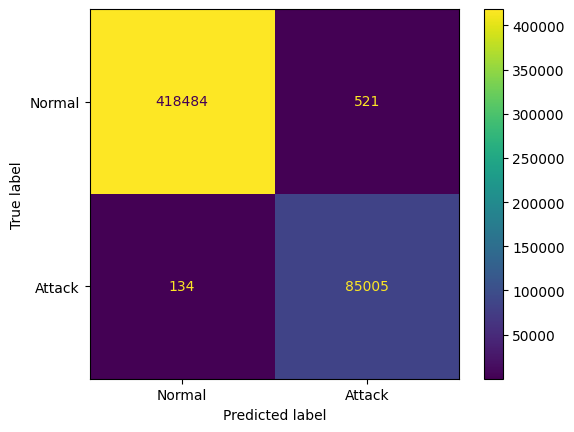

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
).plot()

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

ROC-AUC: 0.9997469258325142
PR-AUC: 0.9976864655218766


In [35]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(importance.head(20))

,0
Packet Length Variance,0.086903
Average Packet Size,0.084429
Bwd Packet Length Std,0.078769
Max Packet Length,0.064166
Packet Length Std,0.060645
Destination Port,0.051640
Packet Length Mean,0.047531
Bwd Packet Length Mean,0.042033
Fwd Packet Length Mean,0.039093
Init_Win_bytes_forward,0.037108


In [36]:
# Find exact duplicate rows between train and test
train_hash = pd.util.hash_pandas_object(
    train_full,
    index=False
)

test_hash = pd.util.hash_pandas_object(
    test_full,
    index=False
)

overlap_hashes = set(train_hash) & set(test_hash)

print("Exact duplicate rows between train and test:",
      len(overlap_hashes))

Exact duplicate rows between train and test: 13


In [37]:
test_overlap_mask = test_hash.isin(overlap_hashes)

print("Rows to remove from test:",
      test_overlap_mask.sum())

Rows to remove from test: 13


In [38]:
# ============================================
# Find exact duplicates between X_train and X_test
# ============================================

train_features_hash = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_features_hash = pd.util.hash_pandas_object(
    X_test,
    index=False
)

overlap_hashes = set(train_features_hash) & set(test_features_hash)

test_overlap_mask = test_features_hash.isin(overlap_hashes).to_numpy()

print("X_train size:", len(X_train))
print("X_test size:", len(X_test))
print("Exact duplicate feature rows:", len(overlap_hashes))
print("Test rows to remove:", test_overlap_mask.sum())

X_train size: 681110
X_test size: 504144
Exact duplicate feature rows: 156
Test rows to remove: 156


In [39]:
# ============================================
# Check labels of train-test feature duplicates
# ============================================

train_lookup = X_train.copy()
train_lookup["Binary Label"] = y_train.values

test_lookup = X_test.copy()
test_lookup["Binary Label"] = y_test.values

# Hash features only
train_feature_hash = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_feature_hash = pd.util.hash_pandas_object(
    X_test,
    index=False
)

# Keep hashes that appear in both sets
overlap_hashes = set(train_feature_hash) & set(test_feature_hash)

# Get corresponding labels
train_labels_overlap = y_train[
    train_feature_hash.isin(overlap_hashes)
]

test_labels_overlap = y_test[
    test_feature_hash.isin(overlap_hashes)
]

print("Overlapping feature rows in train:",
      len(train_labels_overlap))

print("Overlapping feature rows in test:",
      len(test_labels_overlap))

print("\nTrain labels:")
print(train_labels_overlap.value_counts())

print("\nTest labels:")
print(test_labels_overlap.value_counts())

Overlapping feature rows in train: 156
Overlapping feature rows in test: 156

Train labels:
Binary Label
1    117
0     39
Name: count, dtype: int64

Test labels:
Binary Label
0    131
1     25
Name: count, dtype: int64


In [40]:
# ============================================
# Check whether duplicate feature rows
# have conflicting labels
# ============================================

train_overlap = pd.DataFrame({
    "hash": train_feature_hash,
    "label": y_train.values
})

test_overlap = pd.DataFrame({
    "hash": test_feature_hash,
    "label": y_test.values
})

train_overlap = train_overlap[
    train_overlap["hash"].isin(overlap_hashes)
]

test_overlap = test_overlap[
    test_overlap["hash"].isin(overlap_hashes)
]

# For each duplicated feature pattern,
# check how many unique labels exist in train/test
train_label_counts = train_overlap.groupby("hash")["label"].nunique()
test_label_counts = test_overlap.groupby("hash")["label"].nunique()

print("Feature patterns with multiple labels in TRAIN:",
      (train_label_counts > 1).sum())

print("Feature patterns with multiple labels in TEST:",
      (test_label_counts > 1).sum())

Feature patterns with multiple labels in TRAIN: 0
Feature patterns with multiple labels in TEST: 0


In [41]:
# ============================================
# Remove train-test duplicate FEATURE rows
# ============================================

X_test_clean = X_test.iloc[~test_overlap_mask].copy()
y_test_clean = y_test.iloc[~test_overlap_mask].copy()

print("Original test size:", len(X_test))
print("Clean test size:", len(X_test_clean))
print("Removed:", test_overlap_mask.sum())

Original test size: 504144
Clean test size: 503988
Removed: 156


In [42]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred_rf_clean = rf.predict(X_test_clean)

# Probabilities
y_prob_rf_clean = rf.predict_proba(X_test_clean)[:, 1]

print("Classification Report:")
print(
    classification_report(
        y_test_clean,
        y_pred_rf_clean,
        target_names=["Normal", "Attack"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test_clean, y_prob_rf_clean))

print("PR-AUC:",
      average_precision_score(y_test_clean, y_prob_rf_clean))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_rf_clean))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    418874
      Attack       1.00      1.00      1.00     85114

    accuracy                           1.00    503988
   macro avg       1.00      1.00      1.00    503988
weighted avg       1.00      1.00      1.00    503988

ROC-AUC: 0.9998610021117277
PR-AUC: 0.9988017662087094

Confusion Matrix:
[[418470    404]
 [   109  85005]]


In [43]:
# ============================================
# Evaluate Logistic Regression on CLEAN TEST
# ============================================

y_pred_lr_clean = lr.predict(X_test_clean)

y_prob_lr_clean = lr.predict_proba(X_test_clean)[:, 1]

print("Classification Report:")
print(
    classification_report(
        y_test_clean,
        y_pred_lr_clean,
        target_names=["Normal", "Attack"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test_clean, y_prob_lr_clean))

print("PR-AUC:",
      average_precision_score(y_test_clean, y_prob_lr_clean))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_lr_clean))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.90      0.87    418874
      Attack       0.29      0.19      0.23     85114

    accuracy                           0.78    503988
   macro avg       0.57      0.55      0.55    503988
weighted avg       0.75      0.78      0.77    503988

ROC-AUC: 0.5479776434534622
PR-AUC: 0.19186396101853587

Confusion Matrix:
[[378059  40815]
 [ 68638  16476]]


## Decision Tree

In [44]:
# ============================================
# Decision Tree - Training
# ============================================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [45]:
# ============================================
# Decision Tree - Evaluation
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred_dt = dt.predict(X_test_clean)

# Probabilities
y_prob_dt = dt.predict_proba(X_test_clean)[:, 1]

print("Classification Report:")
print(
    classification_report(
        y_test_clean,
        y_pred_dt,
        target_names=["Normal", "Attack"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test_clean, y_prob_dt))

print("PR-AUC:",
      average_precision_score(y_test_clean, y_prob_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_dt))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    418874
      Attack       1.00      1.00      1.00     85114

    accuracy                           1.00    503988
   macro avg       1.00      1.00      1.00    503988
weighted avg       1.00      1.00      1.00    503988

ROC-AUC: 0.9990214080625115
PR-AUC: 0.9942849733653516

Confusion Matrix:
[[418453    421]
 [   118  84996]]


## XGBoost

In [46]:
# ============================================
# XGBoost - Training
# ============================================

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [47]:
# =============================================
# Evaluate XGBoost on CLEAN TEST
# =============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred_xgb_clean = xgb.predict(X_test_clean)

# Probabilities
y_prob_xgb_clean = xgb.predict_proba(X_test_clean)[:, 1]

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test_clean,
        y_pred_xgb_clean,
        target_names=["Normal", "Attack"]
    )
)

# ROC-AUC
print("ROC-AUC:",
      roc_auc_score(y_test_clean, y_prob_xgb_clean))

# PR-AUC
print("PR-AUC:",
      average_precision_score(y_test_clean, y_prob_xgb_clean))

# Confusion Matrix
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_clean,
        y_pred_xgb_clean
    )
)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    418874
      Attack       0.99      1.00      1.00     85114

    accuracy                           1.00    503988
   macro avg       1.00      1.00      1.00    503988
weighted avg       1.00      1.00      1.00    503988

ROC-AUC: 0.999966691444711
PR-AUC: 0.9998423927077857

Confusion Matrix:
[[418299    575]
 [    46  85068]]


## MLP Neural Network - Deep Learning Model

In [48]:
# =============================================
# MLP Neural Network - Deep Learning Model
# =============================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =============================================
# Class Weights
# =============================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

# =============================================
# Build MLP
# =============================================

mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mlp.summary()

# =============================================
# Train
# =============================================

history = mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=512,
    class_weight=class_weights,
    verbose=1
)

print("\nMLP training completed.")

Class weights:
{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,153 (67.00 KB)

 Trainable params: 17,153 (67.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9520 - loss: 0.1178 - val_accuracy: 0.9687 - val_loss: 0.0701
Epoch 2/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9719 - loss: 0.0725 - val_accuracy: 0.9787 - val_loss: 0.0565
Epoch 3/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9763 - loss: 0.0623 - val_accuracy: 0.9822 - val_loss: 0.0502
Epoch 4/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9786 - loss: 0.0577 - val_accuracy: 0.9805 - val_loss: 0.0488
Epoch 5/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9792 - loss: 0.0554 - val_accuracy: 0.9802 - val_loss: 0.0493
Epoch 6/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9801 - loss: 0.0534 - val_accuracy: 0.9812 - val_loss: 0.0492
Epoch 7/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9806 - loss: 0.0524 - val_accuracy: 0.9841 - val_loss: 0.0430
Epoch 8/15
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9807 - loss: 0.052

In [49]:
print([name for name in globals() if "scal" in name.lower()])

['StandardScaler', 'scaler', 'X_train_scaled', 'X_test_scaled']


In [50]:
# =============================================
# Scale CLEAN TEST using the same scaler
# =============================================

X_test_clean_scaled = scaler.transform(X_test_clean)

print("Scaled clean test shape:", X_test_clean_scaled.shape)

Scaled clean test shape: (503988, 52)


In [51]:
# =============================================
# Evaluate MLP on CLEAN TEST
# =============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Probability predictions
y_prob_mlp = mlp.predict(
    X_test_clean_scaled,
    batch_size=1024,
    verbose=0
).ravel()

# Convert probabilities to class labels
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test_clean,
        y_pred_mlp,
        target_names=["Normal", "Attack"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test_clean, y_prob_mlp))

print("PR-AUC:",
      average_precision_score(y_test_clean, y_prob_mlp))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_clean,
        y_pred_mlp
    )
)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99    418874
      Attack       0.89      0.99      0.94     85114

    accuracy                           0.98    503988
   macro avg       0.94      0.98      0.96    503988
weighted avg       0.98      0.98      0.98    503988

ROC-AUC: 0.9987803272406118
PR-AUC: 0.9944946772843506

Confusion Matrix:
[[407908  10966]
 [   614  84500]]


In [52]:
# ============================================
# Create CLEAN scaled test set for MLP
# ============================================

X_test_clean_scaled = scaler.transform(X_test_clean)

print("X_test_clean shape:", X_test_clean.shape)
print("X_test_clean_scaled shape:", X_test_clean_scaled.shape)
print("y_test_clean shape:", y_test_clean.shape)

X_test_clean shape: (503988, 52)
X_test_clean_scaled shape: (503988, 52)
y_test_clean shape: (503988,)


In [53]:
# ============================================
# MLP prediction on CLEAN TEST
# ============================================

y_prob_mlp = mlp.predict(
    X_test_clean_scaled,
    batch_size=1024,
    verbose=0
).ravel()

y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print("MLP predictions:", len(y_pred_mlp))
print("MLP probabilities:", len(y_prob_mlp))

MLP predictions: 503988
MLP probabilities: 503988


## FINAL MODEL COMPARISON

In [54]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred_dt = dt.predict(X_test_clean)
y_pred_rf = rf.predict(X_test_clean)
y_pred_xgb = xgb.predict(X_test_clean)

# Probabilities
y_prob_dt = dt.predict_proba(X_test_clean)[:, 1]
y_prob_rf = rf.predict_proba(X_test_clean)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_clean)[:, 1]


def get_metrics(name, y_true, y_pred, y_prob):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


results = pd.DataFrame([
    get_metrics(
        "Decision Tree",
        y_test_clean,
        y_pred_dt,
        y_prob_dt
    ),

    get_metrics(
        "Random Forest",
        y_test_clean,
        y_pred_rf,
        y_prob_rf
    ),

    get_metrics(
        "XGBoost",
        y_test_clean,
        y_pred_xgb,
        y_prob_xgb
    ),

    get_metrics(
        "MLP Neural Network",
        y_test_clean,
        y_pred_mlp,
        y_prob_mlp
    )
])

# Display
display(
    results.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Decision Tree,0.9989,0.9951,0.9986,0.9968,0.9990,0.9943
1,Random Forest,0.9990,0.9953,0.9987,0.9970,0.9999,0.9988
2,XGBoost,0.9988,0.9933,0.9995,0.9964,1.0000,0.9998
3,MLP Neural Network,0.9770,0.8851,0.9928,0.9359,0.9988,0.9945


## 2️⃣ ROC Curve + PR Curve للـ4 Models

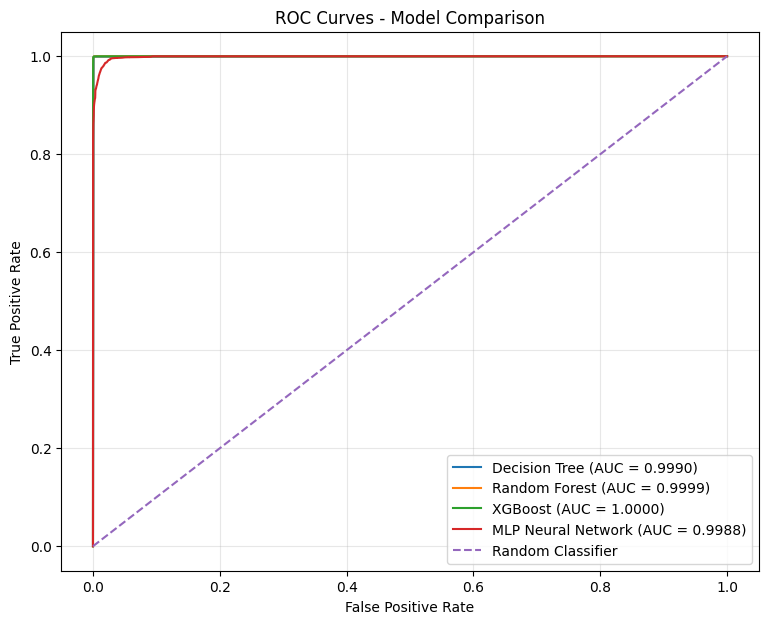

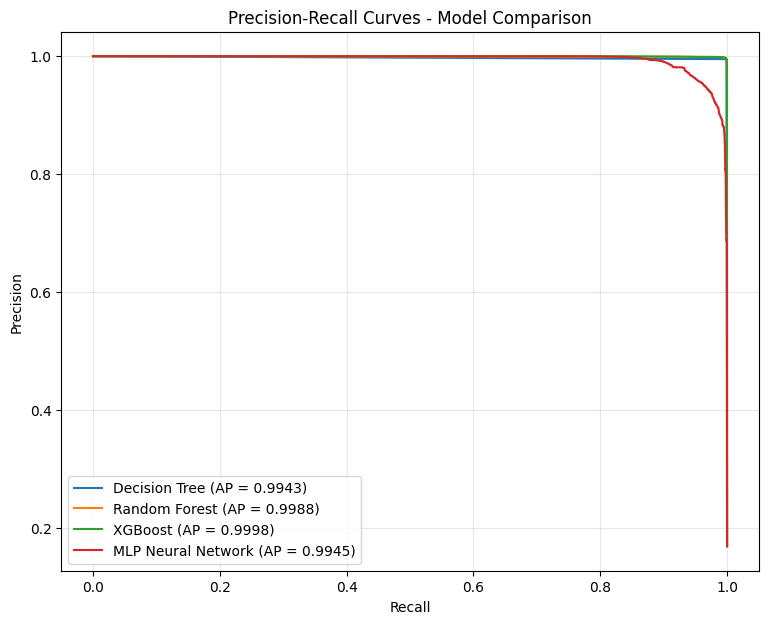

In [55]:
# ============================================
# ROC CURVE + PR CURVE
# ============================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

models_prob = {
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "MLP Neural Network": y_prob_mlp
}


# ============================================
# ROC CURVE
# ============================================

plt.figure(figsize=(9, 7))

for name, y_prob in models_prob.items():

    fpr, tpr, _ = roc_curve(
        y_test_clean,
        y_prob
    )

    roc_score = roc_auc_score(
        y_test_clean,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - Model Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# PRECISION-RECALL CURVE
# ============================================

plt.figure(figsize=(9, 7))

for name, y_prob in models_prob.items():

    precision, recall, _ = precision_recall_curve(
        y_test_clean,
        y_prob
    )

    pr_score = average_precision_score(
        y_test_clean,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {pr_score:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curves - Model Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 3️⃣ MLP Training Curves

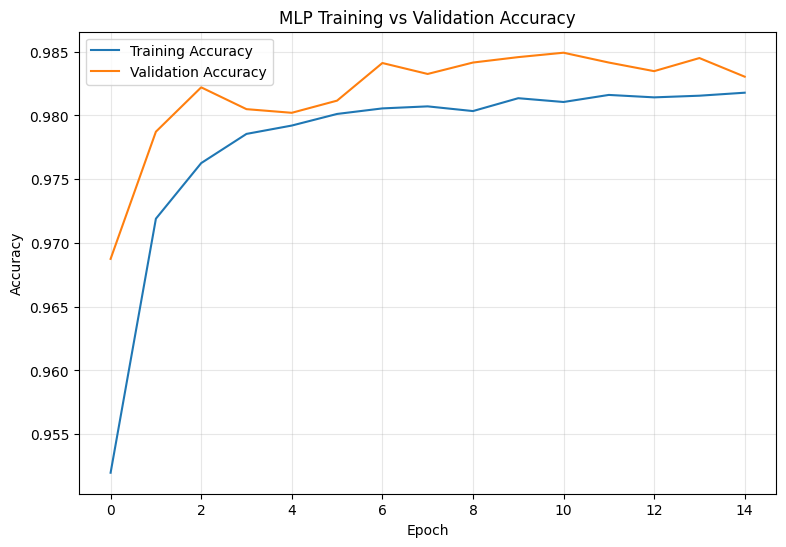

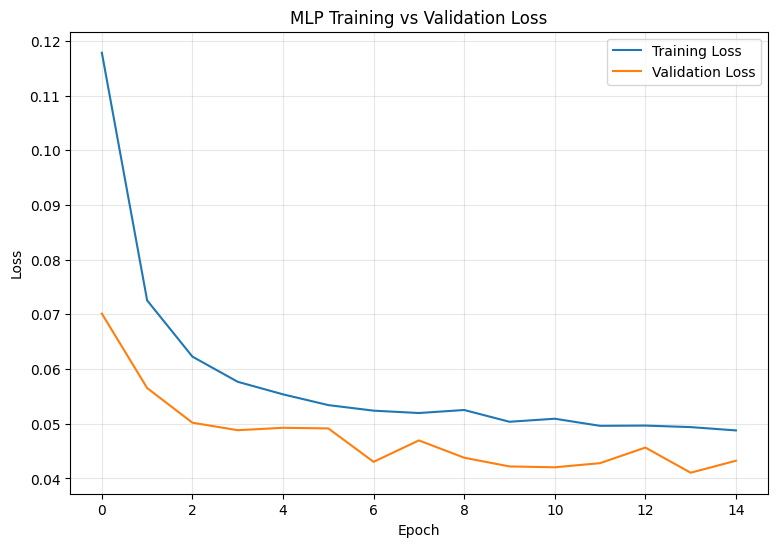

In [56]:
# ============================================
# MLP TRAINING CURVES
# ============================================

import matplotlib.pyplot as plt


# ============================================
# Accuracy
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("MLP Training vs Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# Loss
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("MLP Training vs Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


Decision Tree
[[418453    421]
 [   118  84996]]


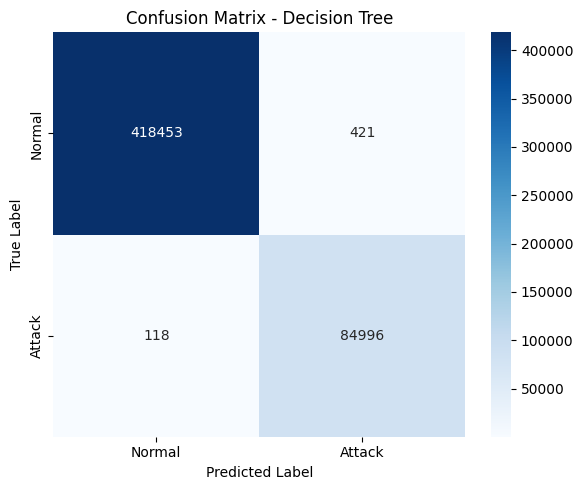


Random Forest
[[418470    404]
 [   109  85005]]


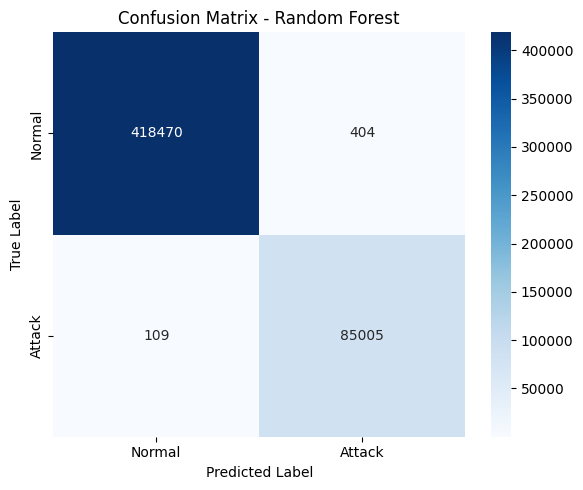


XGBoost
[[418299    575]
 [    46  85068]]


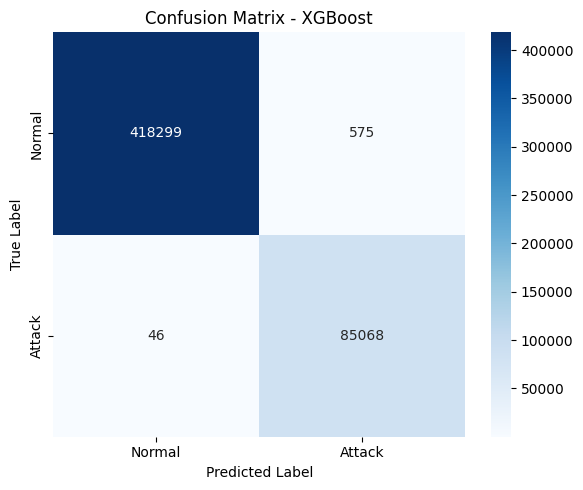


MLP Neural Network
[[407908  10966]
 [   614  84500]]


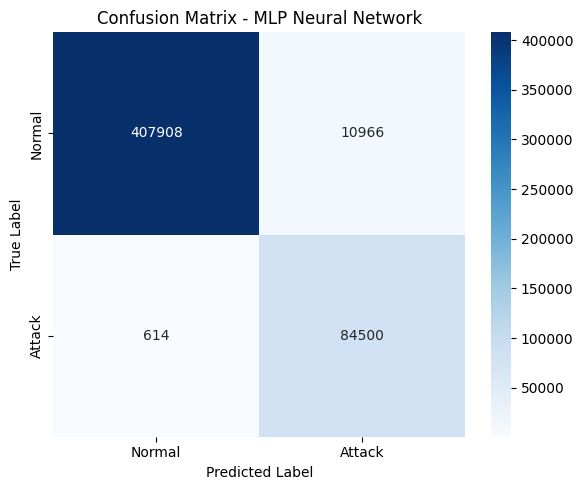

In [57]:
# ============================================
# CONFUSION MATRICES - ALL MODELS
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model_predictions = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "MLP Neural Network": y_pred_mlp
}

for name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test_clean,
        predictions
    )

    print(f"\n{name}")
    print(cm)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

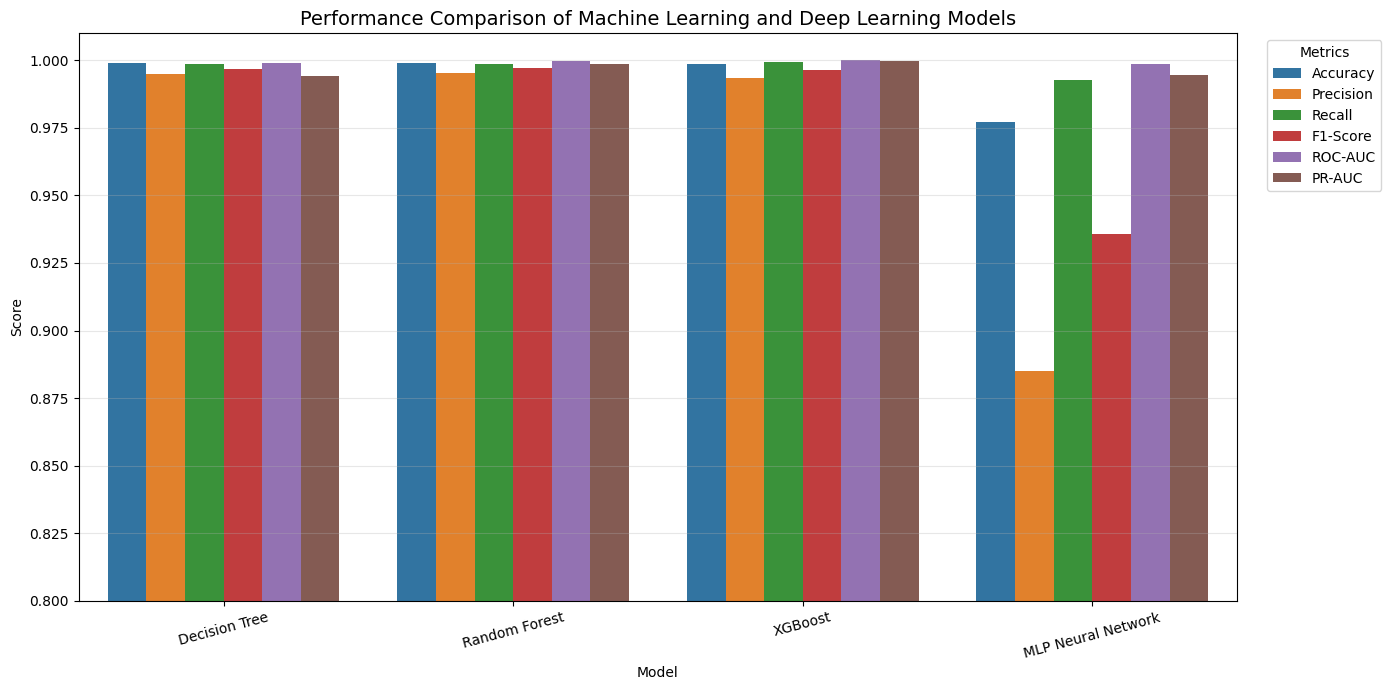

In [58]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

plot_data = results.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Performance Comparison of Machine Learning and Deep Learning Models",
    fontsize=14
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0.8, 1.01)

plt.xticks(rotation=15)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()